# **E-commerce Sales Analysis Project**

## **Dataset Overview**

This dataset contains real-world e-commerce transaction data from a UK-based online retailer.

The dataset includes 541,909 records and 8 features representing invoice transactions, products, quantities, prices, customers, and countries.

---

## **Key Columns**

- InvoiceNo: Unique invoice identifier
- StockCode: Product code
- Description: Product name
- Quantity: Number of items purchased
- InvoiceDate: Date and time of transaction
- UnitPrice: Price per unit
- CustomerID: Unique customer identifier
- Country: Customer country

---

## **Project Objective**

This project analyzes transactional data from a UK-based online retailer to uncover insights about:

* Sales performance
* Customer behavior
* Product demand
* Retention & returns

## **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## **Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/My Drive/Online Retail.xlsx'
df = pd.read_excel(file_path)

print('Shape:',df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## **Data Overview**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.describe(include='object')

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


## **Clean Column Names**

In [15]:
df.columns = df.columns.str.lower()
df.columns.tolist()

['invoiceno',
 'stockcode',
 'description',
 'quantity',
 'invoicedate',
 'unitprice',
 'customerid',
 'country']

### **Missing Values**

In [7]:
# check missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
# percentage of missing values
df.isnull().sum()/len(df)*100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


In [10]:
# drop rows where description is missing
df = df[df['description'].notna()].copy()

# Removed missing Description
# Kept customerid (for sales analysis only)
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64


### **Duplicate Values**

In [11]:
# check Duplicate values
print("duplicates before:", df.duplicated().sum())

duplicates before: 5268


In [12]:
# remove Duplicates values
df = df.drop_duplicates()
print("duplicates after:", df.duplicated().sum())

duplicates after: 0


### **Initial Observations**

After exploring the dataset, several key data quality and structural issues were identified:

1. Missing values were found in:
   - `description`
   - `customerid`

2. Negative values in `quantity` indicate returned or cancelled transactions.

3. Some `unitprice` values are zero or negative, which likely represent data entry errors or invalid transactions.

4. `customerid` is stored as a float, which is not ideal for categorical identification.

5. The dataset contains ***duplicate records***

---

These issues were handled during cleaning to ensure accurate and reliable analysis.

## **Observe Features:**

In [17]:
df['invoiceno'].head()

,invoiceno
0,536365
1,536365
2,536365
3,536365
4,536365


In [18]:
df['invoiceno'] = df['invoiceno'].astype(str)
df[['invoiceno', 'quantity']].where(df['invoiceno'].str.startswith('C'))

,invoiceno,quantity
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
541904,NaN,NaN
541905,NaN,NaN
541906,NaN,NaN
541907,NaN,NaN


#### *Invoice Analysis*

Some InvoiceNo values start with "C", indicating cancelled transactions.
These transactions are having negative quantites.

## **Separate Returns from Sales**

In [19]:
df_sales = df[df['quantity'] >0].copy()
df_returns =  df[df['quantity'] <0].copy()

## **Price**

In [20]:
df_sales['unitprice'].describe()

,unitprice
count,525462.000000
mean,3.876109
std,42.040021
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,13541.330000


## **Clean Price**

In [21]:
df_sales[df_sales['unitprice']<0]

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [22]:
df_sales[df_sales['unitprice']==0]

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524622,580609,22927,Amazon,1,2011-12-05 11:41:00,0.0,NaN,United Kingdom
535325,581202,23404,check,41,2011-12-07 18:30:00,0.0,NaN,United Kingdom
535334,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom


In [23]:
# remove zero or negative prices
df_sales = df_sales[df_sales['unitprice']>0].copy()

In [24]:
print("rows after price cleaning:", len(df_sales))
df_sales['unitprice'].describe()

rows after price cleaning: 524878


,unitprice
count,524878.000000
mean,3.922573
std,36.093028
min,0.001000
25%,1.250000
50%,2.080000
75%,4.130000
max,13541.330000


## **Feature Engineering**

In [25]:
# total price per row
df_sales['total_price'] = df_sales['quantity'] * df_sales['unitprice']

In [ ]:
# fix date column
df_sales['invoicedate'] = pd.to_datetime(df_sales['invoicedate'])

In [26]:
# customerid as number (not string)
df_sales['customerid'] = pd.to_numeric(df_sales['customerid'], errors='coerce')

In [36]:
# extract date parts
df_sales['year']= df_sales['invoicedate'].dt.year
df_sales['month']= df_sales['invoicedate'].dt.month
df_sales['hour'] = df_sales['invoicedate'].dt.hour
df_sales['month_year'] = df_sales['invoicedate'].dt.to_period('M')

## **Basic Key Metrics (KPIs)**

In [28]:
total_revenue = df_sales['total_price'].sum()
total_orders = df_sales['invoiceno'].nunique()
total_customers = df_sales['customerid'].nunique()
total_products = df_sales['description'].nunique()

print(f"Total Revenue:    £{total_revenue:,.2f}")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Revenue:    £10,642,110.80
Total Orders: 19960
Total Customers: 4338
Total Products: 4026


## ***Exploratory Data Analysis (EDA)***

### ***Sales Analysis***





### **Monthly Trend**

In [72]:
monthly_sales = df_sales.groupby('month_year')['total_price'].sum().sort_index()
monthly_sales

,total_price
month_year,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


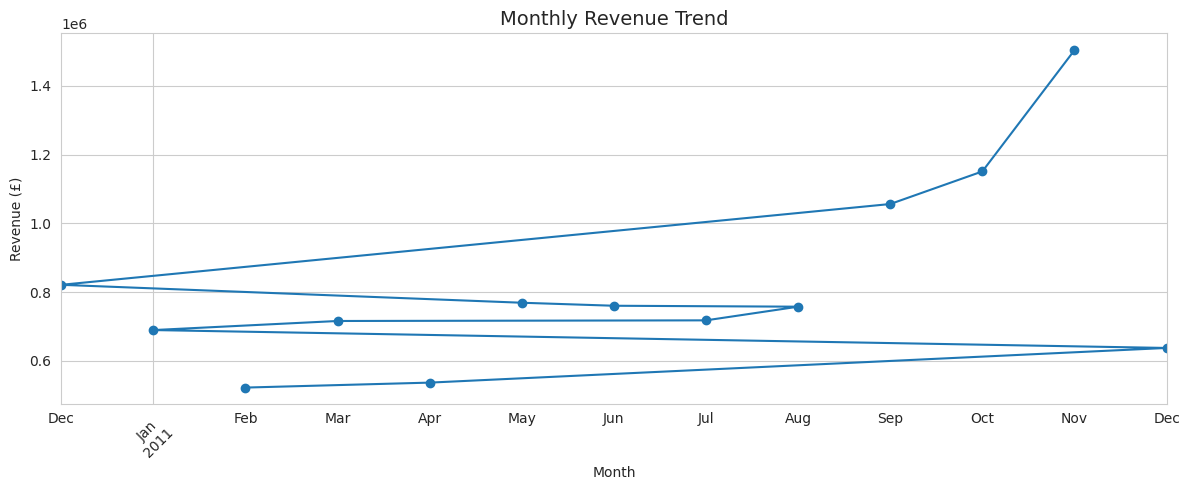

In [33]:
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### *Insight*

Sales show noticeable fluctuations across months, indicating potential seasonal demand patterns.

This suggests that the business could benefit from aligning marketing campaigns and inventory planning with peak sales periods.

### ***Product***

### **Top Products (Revenue)**

In [46]:
top_products_revenue = df_sales.groupby('description')['total_price'].sum().sort_values(ascending=False).head(10)
top_products_revenue

,total_price
description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


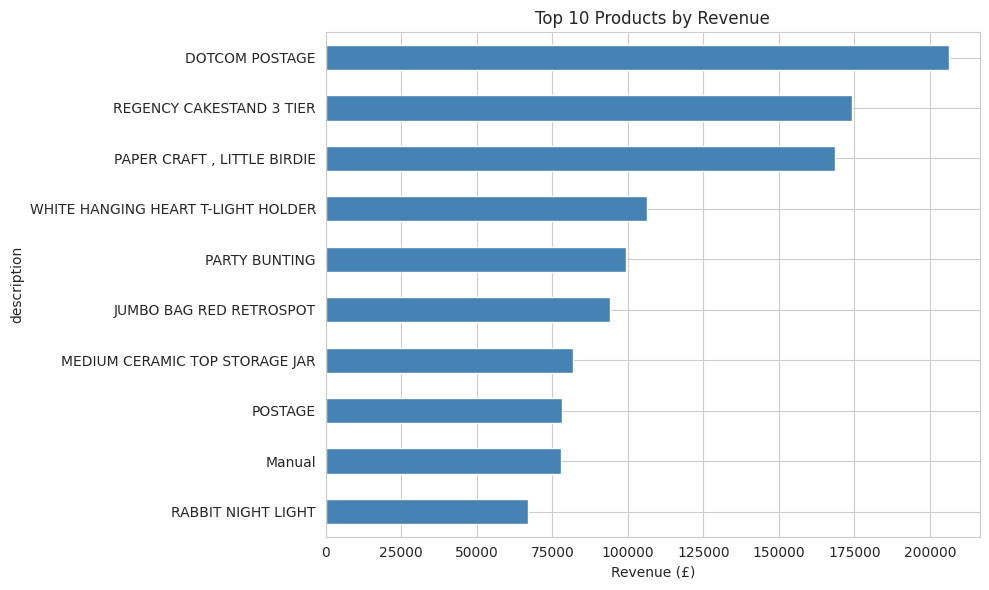

In [47]:
plt.figure(figsize=(10, 6))
top_products_revenue.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

### *Insight*

A limited number of products generate a significant share of total revenue, indicating product concentration.

Focusing on these high-performing products can maximize profitability, while low-performing products may require optimization or replacement.

### **Top Products (Quantity)**

In [48]:
top_products_quantity = df_sales.groupby('description')['quantity'].sum().nlargest(10)
top_products_quantity

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


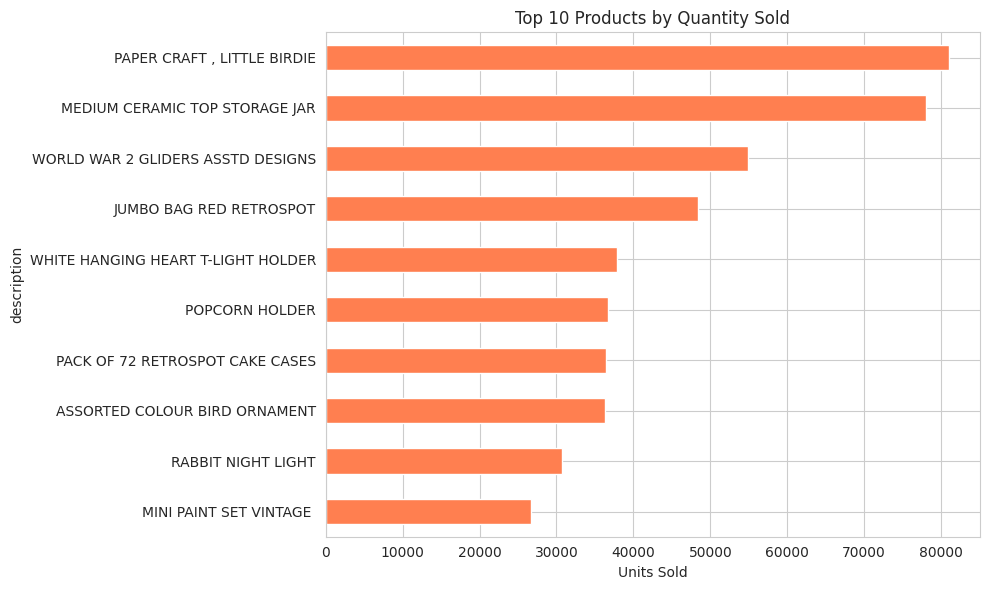

In [49]:
plt.figure(figsize=(10, 6))
top_products_quantity.sort_values().plot(kind='barh', color='coral', edgecolor='white')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Units Sold')
plt.tight_layout()
plt.show()

### *Insight*

Some products are frequently purchased in high quantities but may not generate equivalent revenue.

This suggests opportunities to adjust pricing strategies or bundle offers to increase profitability.

## ***Country Analysis***

In [50]:
country_sales = df_sales.groupby('country')['total_price'].sum().nlargest(10)
country_sales

,total_price
country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


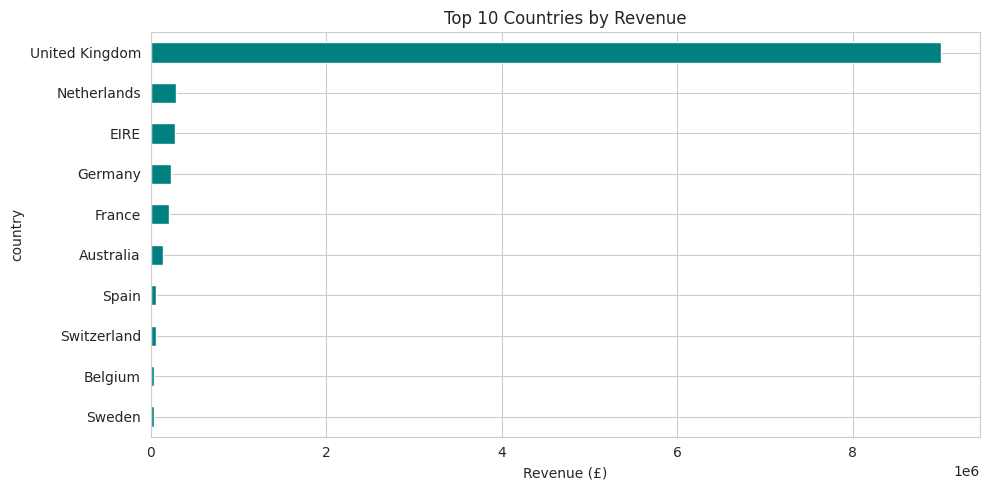

In [51]:
plt.figure(figsize=(10, 5))
country_sales.sort_values().plot(kind='barh', color='teal', edgecolor='white')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [52]:
uk_pct = country_sales['United Kingdom'] / df_sales['total_price'].sum() * 100
print(f"UK accounts for {uk_pct:.1f}% of total revenue")

UK accounts for 84.6% of total revenue


### *Insight*

The *United Kingdom* contributes the majority of total revenue, indicating a high geographic concentration.

This creates a potential risk, and expanding into other markets could improve revenue diversification and long-term stability.

## ***Customer Analysis***

In [73]:
# only keep rows where customer is known
df_customers = df_sales[df_sales['customerid'].notna()].copy()

In [74]:
# total spending per customer
customer_spending = df_customers.groupby('customerid')['total_price'].sum()

### **Customer Spending Distribution**

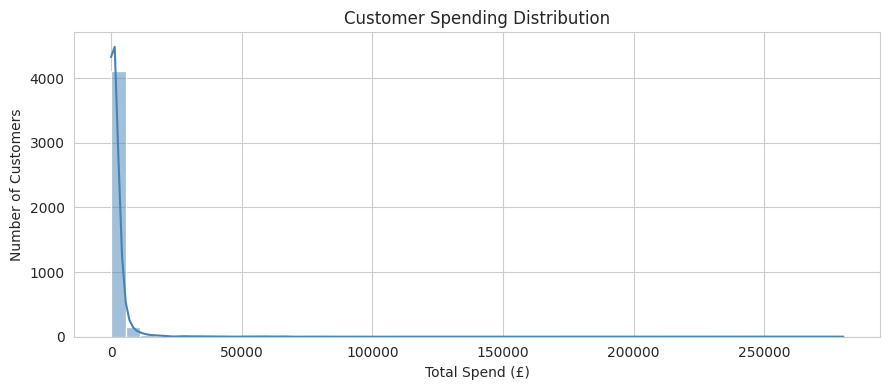

In [75]:
plt.figure(figsize=(9, 4))
sns.histplot(customer_spending, bins=50, kde=True, color='steelblue')

plt.title('Customer Spending Distribution')
plt.xlabel('Total Spend (£)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()


In [76]:
# summary statistics
print(f"Average customer spend: £{customer_spending.mean():,.2f}")
print(f"Median customer spend:  £{customer_spending.median():,.2f}")

Average customer spend: £2,048.69
Median customer spend:  £668.57


### *Insight*

Customer spending shows a highly skewed distribution, where a small number of customers contribute significantly to total revenue.

This indicates that the business relies heavily on high-value customers, highlighting the importance of retention strategies.

## **Outlier Check on Total Price**

In [57]:
Q1 = df_sales['total_price'].quantile(0.25)
Q3 = df_sales['total_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_sales[(df_sales['total_price'] < lower) | (df_sales['total_price'] > upper)]

print(f"Number of outliers: {len(outliers)}")
print(f"These are likely bulk orders - keeping them in the analysis")
outliers.sort_values('total_price', ascending=False).head(10)

Number of outliers: 42624
These are likely bulk orders - keeping them in the analysis


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,total_price,year,month,day of week,hour,month_year,day_of_week
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60,2011,12,<bound method PandasDelegate._add_delegate_acc...,9,2011-12,<bound method PandasDelegate._add_delegate_acc...
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60,2011,1,<bound method PandasDelegate._add_delegate_acc...,10,2011-01,<bound method PandasDelegate._add_delegate_acc...
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00,2011,6,<bound method PandasDelegate._add_delegate_acc...,15,2011-06,<bound method PandasDelegate._add_delegate_acc...
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33,2010,12,<bound method PandasDelegate._add_delegate_acc...,15,2010-12,<bound method PandasDelegate._add_delegate_acc...
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06,2011,8,<bound method PandasDelegate._add_delegate_acc...,14,2011-08,<bound method PandasDelegate._add_delegate_acc...
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75,2011,5,<bound method PandasDelegate._add_delegate_acc...,13,2011-05,<bound method PandasDelegate._add_delegate_acc...
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72,2011,9,<bound method PandasDelegate._add_delegate_acc...,11,2011-09,<bound method PandasDelegate._add_delegate_acc...
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40,2011,4,<bound method PandasDelegate._add_delegate_acc...,13,2011-04,<bound method PandasDelegate._add_delegate_acc...
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40,2011,1,<bound method PandasDelegate._add_delegate_acc...,12,2011-01,<bound method PandasDelegate._add_delegate_acc...
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00,2011,10,<bound method PandasDelegate._add_delegate_acc...,12,2011-10,<bound method PandasDelegate._add_delegate_acc...


### *Insight*

Outliers in transaction values likely represent bulk purchases or high-value customers.

Since these reflect real business behavior, they were retained in the analysis rather than removed.

## **RFM Analysis**

RFM (Recency, Frequency, Monetary) is a customer segmentation technique used to identify high-value customers based on their purchasing behavior.

- Recency: How recently a customer made a purchase
- Frequency: How often they purchase
- Monetary: How much they spend

This helps the business:
- Identify loyal customers
- Detect customers at risk of churn
- Target marketing campaigns effectively

In [58]:
# only use customers we know
df_rfm = df_sales[df_sales['customerid'].notna()].copy()

# reference date = day after last transaction
snapshot = df_rfm['invoicedate'].max() + pd.Timedelta(days=1)

rfm = df_rfm.groupby('customerid').agg({
    'invoicedate': lambda x: (snapshot - x.max()).days,
    'invoiceno': 'nunique',
    'total_price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

### **RFM Scoring**

In [59]:
# score each dimension 1-5 using quantiles
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total
customerid,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


### **Customer Segments**

In [60]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalist'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f >= 3:
        return 'Cannot Lose'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal Customer        1003
Champion               957
Hibernating            821
Needs Attention        494
At Risk                442
New Customer           319
Cannot Lose            201
Potential Loyalist     101
Name: count, dtype: int64


### **Segment Visualisation**

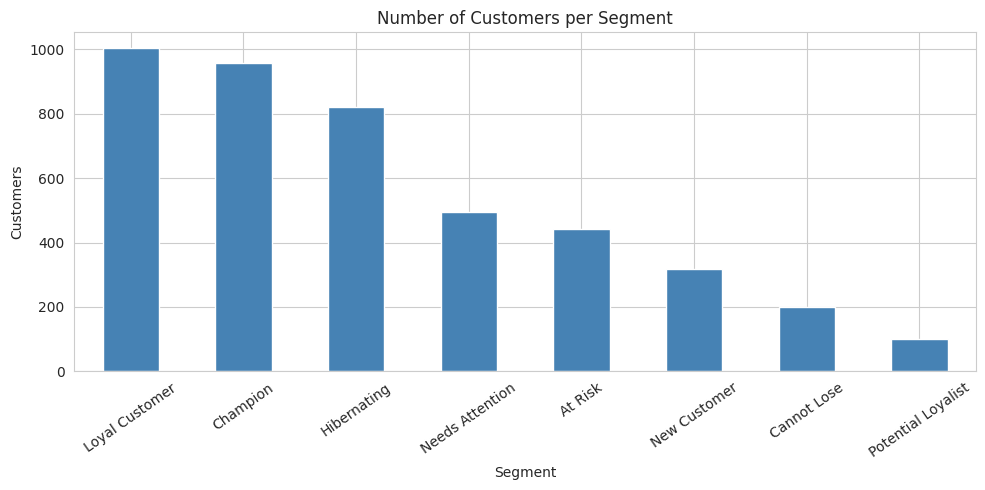

In [61]:
seg_count = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))
seg_count.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Customers per Segment')
plt.xlabel('Segment')
plt.ylabel('Customers')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### **Business Insight**

- **Champions** are the most valuable customers and should be prioritized for retention.
- **Loyal Customers** contribute steady revenue and can be targeted with loyalty programs.
- **At Risk** customers may churn and require re-engagement strategies.
- **Hibernating** customers show low engagement and may need activation campaigns.

## **K-Means Clustering**

K-Means clustering was applied to group customers into segments based on their RFM values.

This provides:
- Data-driven segmentation
- Identification of hidden customer groups
- Support for targeted marketing strategies

In [64]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# scale the data first - important step!
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# find best number of clusters using elbow method
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

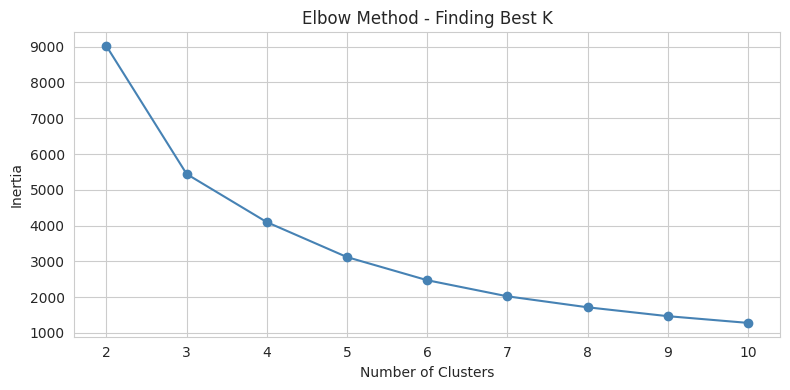

In [65]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [66]:
# based on elbow, pick k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_scaled)

# check what each cluster looks like
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

,Recency,Frequency,Monetary
Cluster,,,
0,247.1,1.6,629.7
1,41.5,4.7,1849.7
2,6.0,66.4,85826.1


### *Insight*

Clusters show distinct customer behavior patterns:
- One cluster represents high-value customers
- Another represents low-engagement customers
- This confirms the segmentation obtained from RFM

## **Return Analysis**

In [67]:
df_returns['invoicedate']    = pd.to_datetime(df_returns['invoicedate'])
df_returns['quantity_abs']   = df_returns['quantity'].abs()

return_rate = df_returns['quantity_abs'].sum() / df_sales['quantity'].sum() * 100
print(f"Return rate (by quantity): {return_rate:.1f}%")

top_returned = (df_returns.groupby('description')['quantity_abs']
    .sum().sort_values(ascending=False).head(10))


Return rate (by quantity): 7.8%


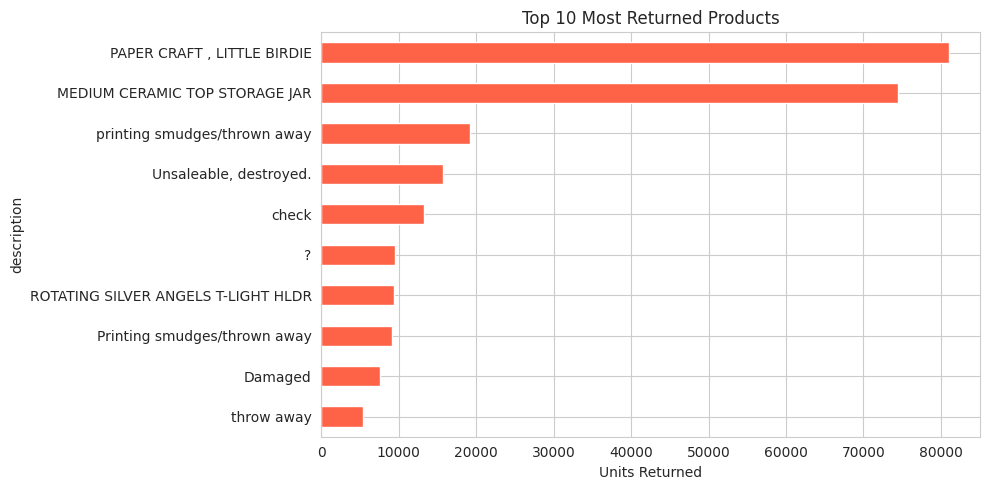

In [68]:
plt.figure(figsize=(10, 5))
top_returned.sort_values().plot(kind='barh', color='tomato', edgecolor='white')
plt.title('Top 10 Most Returned Products')
plt.xlabel('Units Returned')
plt.tight_layout()
plt.show()

### *Insight*

Return rate measures the proportion of sold items that were returned.

A high return rate may indicate:
- Product quality issues
- Customer dissatisfaction
- Mismatch between expectations and reality

## **Summary & Insights**


In [69]:
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"\nTotal Revenue:       £{total_revenue:,.0f}")
print(f"Total Orders:        {total_orders:,}")
print(f"Unique Customers:    {total_customers:,}")
print(f"Countries Served:    {df_sales['country'].nunique()}")
print(f"UK Revenue Share:    {uk_pct:.1f}%")
print(f"Return Rate:         {return_rate:.1f}%")
print(f"\nChampion Customers:  {(rfm['Segment']=='Champion').sum()}")
print(f"At Risk Customers:   {(rfm['Segment']=='At Risk').sum()}")
print(f"Hibernating:         {(rfm['Segment']=='Hibernating').sum()}")

PROJECT SUMMARY

Total Revenue:       £10,642,111
Total Orders:        19,960
Unique Customers:    4,338
Countries Served:    38
UK Revenue Share:    84.6%
Return Rate:         7.8%

Champion Customers:  957
At Risk Customers:   442
Hibernating:         821


# Business Insights
## Key Findings:
* The UK dominates total sales → high dependency risk.
* Few customers generate most revenue
* Top products drive business
* Seasonal trends present
## Recommendations
* Focus on retaining top customers.
* Promote high-performing products.
* Expand to new markets outside the UK.
* Optimize low-performing products(retention)